In [1]:
# WEEKLY LUNCH-BOX PLANNING USING NSGA-II
# QUESTION - 3
# INTEGER-CODED MULTI-OBJECTIVE OPTIMIZATION


import random
import copy
import matplotlib.pyplot as plt


# NSGA-II PARAMETERS

POPULATION_SIZE = 100
GENERATIONS = 250

CROSSOVER_PROBABILITY = 0.90
MUTATION_PROBABILITY = 0.05



# PROBLEM PARAMETERS

# Monday to Friday Planning
NUMBER_OF_DAYS = 5

# Four Items Per Day
GENES_PER_DAY = 4

# Total Genes = 5 Days × 4 Items
TOTAL_GENES = 20


# CONSTRAINT PARAMETERS

WEEKLY_BUDGET = 3000

MINIMUM_DAILY_NUTRITION = 20
MAXIMUM_DAILY_WEIGHT = 1000

MINIMUM_UNIQUE_MAIN_ITEMS = 3
MINIMUM_UNIQUE_FRUITS = 3

MAXIMUM_CHICKEN_SELECTION = 3


# MAIN ITEMS

MAIN = {

    1: {"name": "Chicken Sandwich",
        "cost": 450,
        "weight": 220,
        "score": 8},

    2: {"name": "Chicken Wrap",
        "cost": 400,
        "weight": 200,
        "score": 8},

    3: {"name": "Chickpea Chaat",
        "cost": 220,
        "weight": 250,
        "score": 7},

    4: {"name": "Daal with Two Rotis",
        "cost": 250,
        "weight": 350,
        "score": 8},

    5: {"name": "Small Chicken Pulao",
        "cost": 350,
        "weight": 350,
        "score": 9}
}

# FRUITS / VEGETABLES

FRUIT_VEG = {

    1: {"name": "Apple",
        "cost": 120,
        "weight": 150,
        "score": 5},

    2: {"name": "Banana",
        "cost": 60,
        "weight": 120,
        "score": 4},

    3: {"name": "Orange",
        "cost": 100,
        "weight": 150,
        "score": 5},

    4: {"name": "Vegetable Salad",
        "cost": 250,
        "weight": 180,
        "score": 7},

    5: {"name": "Cucumber-Carrot Salad",
        "cost": 100,
        "weight": 150,
        "score": 5}
}

# PROTEIN / DAIRY SIDES

SIDE = {

    1: {"name": "One Boiled Egg",
        "cost": 30,
        "weight": 60,
        "score": 5},

    2: {"name": "Yogurt Cup",
        "cost": 150,
        "weight": 100,
        "score": 6},

    3: {"name": "Roasted Chickpeas",
        "cost": 100,
        "weight": 80,
        "score": 6},

    4: {"name": "Two Boiled Eggs",
        "cost": 60,
        "weight": 120,
        "score": 9},

    5: {"name": "Small Mixed Nuts Pack",
        "cost": 180,
        "weight": 40,
        "score": 7}
}

# BEVERAGES

BEVERAGE = {

    1: {"name": "Water Bottle",
        "cost": 60,
        "weight": 500,
        "score": 2},

    2: {"name": "Small Milk Pack",
        "cost": 170,
        "weight": 250,
        "score": 6},

    3: {"name": "Small Fruit Juice",
        "cost": 120,
        "weight": 200,
        "score": 4},

    4: {"name": "Small Lassi",
        "cost": 160,
        "weight": 250,
        "score": 6},

    5: {"name": "Lemon Water",
        "cost": 80,
        "weight": 300,
        "score": 3}
}
print("Block-1 Executed Successfully.")

Block-1 Executed Successfully.


In [2]:
# POPULATION INITIALIZATION

# Create One Weekly Lunch-Box Chromosome
def create_chromosome():

    chromosome = []

    for day in range(NUMBER_OF_DAYS):

        # Main Item
        chromosome.append(random.randint(1, 5))

        # Fruit / Vegetable
        chromosome.append(random.randint(1, 5))

        # Protein / Dairy Side
        chromosome.append(random.randint(1, 5))

        # Beverage
        chromosome.append(random.randint(1, 5))

    return chromosome


# INITIALIZE POPULATION

def initialize_population():

    population = []

    for _ in range(POPULATION_SIZE):

        solution = {

            "chromosome": create_chromosome()

        }

        population.append(solution)

    return population


print("Block-2 Executed Successfully.")

Block-2 Executed Successfully.


In [3]:
# OBJECTIVE FUNCTION EVALUATION

def evaluate_solution(chromosome):

    total_cost = 0
    total_nutrition = 0

    daily_nutrition = []
    daily_weight = []

    main_items = []
    fruit_items = []
    side_items = []
    beverage_items = []

    chicken_counter = 0


    # Evaluate Monday to Friday Lunch Plans
    for day in range(NUMBER_OF_DAYS):

        index = day * 4

        m = chromosome[index]
        f = chromosome[index + 1]
        s = chromosome[index + 2]
        b = chromosome[index + 3]


        # Weekly Cost

        total_cost += (

            MAIN[m]["cost"] +
            FRUIT_VEG[f]["cost"] +
            SIDE[s]["cost"] +
            BEVERAGE[b]["cost"]

        )


        # Weekly Nutrition Score

        nutrition = (

            MAIN[m]["score"] +
            FRUIT_VEG[f]["score"] +
            SIDE[s]["score"] +
            BEVERAGE[b]["score"]

        )

        total_nutrition += nutrition
        daily_nutrition.append(nutrition)


        # Daily Weight

        weight = (

            MAIN[m]["weight"] +
            FRUIT_VEG[f]["weight"] +
            SIDE[s]["weight"] +
            BEVERAGE[b]["weight"]

        )

        daily_weight.append(weight)


        # Store Selected Items

        main_items.append(m)
        fruit_items.append(f)
        side_items.append(s)
        beverage_items.append(b)


        # Chicken Constraint Counter

        if m in [1, 2]:

            chicken_counter += 1


    # Number of Unique Items

    unique_main = len(set(main_items))
    unique_fruit = len(set(fruit_items))
    unique_side = len(set(side_items))
    unique_beverage = len(set(beverage_items))


    # Objective-3 : Repetition Score

    repetition_score = (

        20 -

        (

            unique_main +
            unique_fruit +
            unique_side +
            unique_beverage

        )

    )


    return {

        "cost": total_cost,

        "nutrition": total_nutrition,

        # NSGA-II minimizes all objectives
        "negative_nutrition": -total_nutrition,

        "repetition": repetition_score,

        "daily_nutrition": daily_nutrition,

        "daily_weight": daily_weight,

        "main_items": main_items,

        "unique_main": unique_main,

        "unique_fruit": unique_fruit,

        "unique_side": unique_side,

        "unique_beverage": unique_beverage,

        "chicken_counter": chicken_counter

    }



# CONSTRAINT EVALUATION

def constraint_violation(chromosome, objectives):

    violation = 0.0


    # Weekly Budget Constraint

    if objectives["cost"] > WEEKLY_BUDGET:

        violation += (

            (objectives["cost"] - WEEKLY_BUDGET)

            / WEEKLY_BUDGET

        )


    # Daily Nutrition Constraint

    for nutrition in objectives["daily_nutrition"]:

        if nutrition < MINIMUM_DAILY_NUTRITION:

            violation += (

                (MINIMUM_DAILY_NUTRITION - nutrition)

                / MINIMUM_DAILY_NUTRITION

            )


    # Daily Weight Constraint

    for weight in objectives["daily_weight"]:

        if weight > MAXIMUM_DAILY_WEIGHT:

            violation += (

                (weight - MAXIMUM_DAILY_WEIGHT)

                / MAXIMUM_DAILY_WEIGHT

            )


    # Unique Main Items Constraint

    if objectives["unique_main"] < MINIMUM_UNIQUE_MAIN_ITEMS:

        violation += (

            (MINIMUM_UNIQUE_MAIN_ITEMS -
             objectives["unique_main"])

            / MINIMUM_UNIQUE_MAIN_ITEMS

        )


    # Unique Fruits Constraint

    if objectives["unique_fruit"] < MINIMUM_UNIQUE_FRUITS:

        violation += (

            (MINIMUM_UNIQUE_FRUITS -
             objectives["unique_fruit"])

            / MINIMUM_UNIQUE_FRUITS

        )


    # Adjacent Main Items Constraint

    main_items = objectives["main_items"]

    for i in range(NUMBER_OF_DAYS - 1):

        if main_items[i] == main_items[i + 1]:

            violation += 1


    # Chicken Selection Constraint

    if objectives["chicken_counter"] > MAXIMUM_CHICKEN_SELECTION:

        violation += (

            (objectives["chicken_counter"] -
             MAXIMUM_CHICKEN_SELECTION)

            / MAXIMUM_CHICKEN_SELECTION

        )


    return violation


print("Block-3 Executed Successfully.")

Block-3 Executed Successfully.


In [4]:
# CONSTRAINT DOMINATION PRINCIPLE


def dominates(solution1, solution2):

    # Prefer Feasible Solutions

    if solution1["violation"] == 0 and solution2["violation"] > 0:
        return True

    if solution1["violation"] > 0 and solution2["violation"] == 0:
        return False


    # If Both Solutions are Infeasible

    if (solution1["violation"] > 0 and
            solution2["violation"] > 0):

        return (

            solution1["violation"]
            <
            solution2["violation"]

        )


    # If Both Solutions are Feasible
    # Apply Pareto Dominance

    cost_better = (

        solution1["objectives"]["cost"]
        <=
        solution2["objectives"]["cost"]

    )


    nutrition_better = (

        solution1["objectives"]["negative_nutrition"]
        <=
        solution2["objectives"]["negative_nutrition"]

    )


    repetition_better = (

        solution1["objectives"]["repetition"]
        <=
        solution2["objectives"]["repetition"]

    )


    strictly_better = (

        solution1["objectives"]["cost"]
        <
        solution2["objectives"]["cost"]

        or

        solution1["objectives"]["negative_nutrition"]
        <
        solution2["objectives"]["negative_nutrition"]

        or

        solution1["objectives"]["repetition"]
        <
        solution2["objectives"]["repetition"]

    )


    return (

        cost_better
        and
        nutrition_better
        and
        repetition_better
        and
        strictly_better

    )



# FAST NON-DOMINATED SORTING

def non_dominated_sort(population):

    fronts = [[]]


    for solution in population:

        solution["domination_count"] = 0
        solution["dominated_solutions"] = []


        for other in population:

            if solution == other:
                continue


            if dominates(solution, other):

                solution["dominated_solutions"].append(
                    other
                )


            elif dominates(other, solution):

                solution["domination_count"] += 1


        if solution["domination_count"] == 0:

            solution["rank"] = 1
            fronts[0].append(solution)


    current_front = 0


    while current_front < len(fronts):

        next_front = []


        for solution in fronts[current_front]:

            for dominated in solution["dominated_solutions"]:

                dominated["domination_count"] -= 1


                if dominated["domination_count"] == 0:

                    dominated["rank"] = current_front + 2

                    next_front.append(dominated)


        if len(next_front) > 0:

            fronts.append(next_front)


        current_front += 1


    return fronts



# CROWDING DISTANCE CALCULATION

def calculate_crowding_distance(front):

    if len(front) == 0:
        return


    # Boundary Solutions

    if len(front) <= 2:

        for solution in front:

            solution["crowding_distance"] = float("inf")

        return


    for solution in front:

        solution["crowding_distance"] = 0


    objectives = [

        "cost",
        "negative_nutrition",
        "repetition"

    ]


    for objective in objectives:


        front.sort(

            key=lambda x:
            x["objectives"][objective]

        )


        front[0]["crowding_distance"] = float("inf")
        front[-1]["crowding_distance"] = float("inf")


        minimum = front[0]["objectives"][objective]
        maximum = front[-1]["objectives"][objective]


        if minimum == maximum:
            continue


        for i in range(1, len(front) - 1):


            previous_value = (

                front[i - 1]["objectives"][objective]

            )


            next_value = (

                front[i + 1]["objectives"][objective]

            )


            distance = (

                (next_value - previous_value)

                /

                (maximum - minimum)

            )


            if front[i]["crowding_distance"] != float("inf"):

                front[i]["crowding_distance"] += distance


print("Block-4 Executed Successfully.")

Block-4 Executed Successfully.


In [5]:
# BINARY TOURNAMENT SELECTION

def tournament_selection(population):

    solution1 = random.choice(population)
    solution2 = random.choice(population)


    # Lower Pareto Rank is Preferred

    if solution1["rank"] < solution2["rank"]:
        return copy.deepcopy(solution1)

    if solution2["rank"] < solution1["rank"]:
        return copy.deepcopy(solution2)


    # Higher Crowding Distance is Preferred

    if (solution1["crowding_distance"]
            >
            solution2["crowding_distance"]):

        return copy.deepcopy(solution1)


    return copy.deepcopy(solution2)



# CATEGORY-PRESERVING CROSSOVER

def crossover(parent1, parent2):

    child1 = copy.deepcopy(
        parent1["chromosome"]
    )

    child2 = copy.deepcopy(
        parent2["chromosome"]
    )


    if random.random() <= CROSSOVER_PROBABILITY:


        # Exchange Complete Day Blocks

        for day in range(NUMBER_OF_DAYS):

            if random.random() < 0.50:

                start = day * 4
                end = start + 4

                child1[start:end] = (

                    parent2["chromosome"][start:end]

                )


                child2[start:end] = (

                    parent1["chromosome"][start:end]

                )


    return child1, child2



# INTEGER REPLACEMENT MUTATION

def mutation(chromosome):

    for gene in range(TOTAL_GENES):

        if random.random() <= MUTATION_PROBABILITY:

            gene_type = gene % 4


            # Main Item

            if gene_type == 0:

                chromosome[gene] = random.randint(1, 5)


            # Fruit / Vegetable

            elif gene_type == 1:

                chromosome[gene] = random.randint(1, 5)


            # Protein / Dairy Side

            elif gene_type == 2:

                chromosome[gene] = random.randint(1, 5)


            # Beverage

            else:

                chromosome[gene] = random.randint(1, 5)


    return chromosome


print("Block-5 Executed Successfully.")

Block-5 Executed Successfully.


In [6]:
# CREATE A COMPLETE SOLUTION

def create_solution(chromosome):

    objectives = evaluate_solution(chromosome)

    solution = {

        "chromosome": chromosome,

        "objectives": objectives,

        "violation": constraint_violation(

            chromosome,
            objectives

        )

    }

    return solution



# ELITIST PARENT-OFFSPRING REPLACEMENT

def elitist_replacement(combined_population):

    fronts = non_dominated_sort(
        combined_population
    )

    new_population = []


    for front in fronts:

        calculate_crowding_distance(front)


        # Add Complete Front

        if (

            len(new_population)
            +
            len(front)

            <=

            POPULATION_SIZE

        ):

            new_population.extend(front)


        # Add Remaining Solutions

        else:

            front.sort(

                key=lambda x:
                x["crowding_distance"],

                reverse=True

            )


            remaining = (

                POPULATION_SIZE
                -
                len(new_population)

            )


            new_population.extend(

                front[:remaining]

            )

            break


    return new_population


# COMPLETE NSGA-II ALGORITHM

def NSGA_II():

    # Initial Population

    chromosomes = initialize_population()


    population = [

        create_solution(
            chromosome["chromosome"]
        )

        for chromosome in chromosomes

    ]


    # Store Generation-wise Progress

    feasible_history = []


    # Evolution Process

    for generation in range(GENERATIONS):


        # Non-dominated Sorting

        fronts = non_dominated_sort(
            population
        )


        # Crowding Distance Calculation

        for front in fronts:

            calculate_crowding_distance(
                front
            )


        # Store Number of Feasible Solutions
        # (One Value Per Generation)

        feasible_count = sum(

            1

            for solution in population

            if solution["violation"] == 0

        )

        feasible_history.append(
            feasible_count
        )


        offspring_population = []


        # Generate Offspring Population

        while (

            len(offspring_population)
            <
            POPULATION_SIZE

        ):


            # Parent Selection

            parent1 = tournament_selection(
                population
            )

            parent2 = tournament_selection(
                population
            )


            # Crossover

            child1, child2 = crossover(

                parent1,
                parent2

            )


            # Mutation

            child1 = mutation(child1)

            child2 = mutation(child2)


            # Create Complete Solutions

            offspring_population.append(

                create_solution(child1)

            )


            if (

                len(offspring_population)
                <
                POPULATION_SIZE

            ):

                offspring_population.append(

                    create_solution(child2)

                )


        # Parent-Offspring Combination

        combined_population = (

            population
            +
            offspring_population

        )


        # Elitist Replacement

        population = elitist_replacement(

            combined_population

        )


    return population, feasible_history


print("Block-6 Executed Successfully.")

Block-6 Executed Successfully.


In [7]:
# EXECUTE NSGA-II ALGORITHM

final_population, feasible_history = NSGA_II()


# DISPLAY BASIC RESULTS

print("\nNSGA-II Executed Successfully.\n")

print("Population Size :", len(final_population))


# FEASIBLE SOLUTIONS

feasible_solutions = [

    solution

    for solution in final_population

    if solution["violation"] == 0

]

print("Feasible Solutions :", len(feasible_solutions))


# PARETO FRONT SOLUTIONS

fronts = non_dominated_sort(
    final_population
)

pareto_front = fronts[0]

calculate_crowding_distance(
    pareto_front
)

print("Pareto Front Solutions :",
      len(pareto_front))


# DISPLAY FIRST FIVE SOLUTIONS

print("\nFIRST FIVE SOLUTIONS")

print("-" * 50)

for solution in final_population[:5]:

    print()

    print(
        solution["objectives"]
    )


# QUESTION - 3 COMPLETED

print("\n" + "=" * 60)
print("QUESTION - 3 COMPLETED")
print("NSGA-II IMPLEMENTATION SUCCESSFUL")
print("=" * 60)


NSGA-II Executed Successfully.

Population Size : 100
Feasible Solutions : 100
Pareto Front Solutions : 100

FIRST FIVE SOLUTIONS
--------------------------------------------------

{'cost': 3000, 'nutrition': 125, 'negative_nutrition': -125, 'repetition': 3, 'daily_nutrition': [24, 24, 26, 23, 28], 'daily_weight': [890, 970, 760, 760, 870], 'main_items': [4, 2, 3, 5, 4], 'unique_main': 4, 'unique_fruit': 5, 'unique_side': 3, 'unique_beverage': 5, 'chicken_counter': 1}

{'cost': 2380, 'nutrition': 106, 'negative_nutrition': -106, 'repetition': 7, 'daily_nutrition': [21, 20, 21, 22, 22], 'daily_weight': [860, 980, 830, 990, 760], 'main_items': [4, 3, 5, 3, 4], 'unique_main': 3, 'unique_fruit': 4, 'unique_side': 3, 'unique_beverage': 3, 'chicken_counter': 0}

{'cost': 2240, 'nutrition': 107, 'negative_nutrition': -107, 'repetition': 10, 'daily_nutrition': [21, 22, 21, 22, 21], 'daily_weight': [860, 990, 830, 990, 860], 'main_items': [4, 3, 5, 3, 4], 'unique_main': 3, 'unique_fruit': 3, 

## uptil now I have completed all steps of Question #1 (Implementation)

## now I will move towards Question 4: Results and Visualization

In [9]:
# QUESTION - 4
# PART - 1
# 10 INDEPENDENT NSGA-II RUNS

NUMBER_OF_RUNS = 10

all_runs = []


for run_number in range(NUMBER_OF_RUNS):

    # Different Random Seed For Every Run

    random.seed(run_number + 1)


    # Execute NSGA-II

    final_population, feasible_history = NSGA_II()


    # Feasible Solutions

    feasible_solutions = [

        solution

        for solution in final_population

        if solution["violation"] == 0

    ]


    # Pareto Front Solutions

    fronts = non_dominated_sort(
        final_population
    )

    pareto_front = fronts[0]


    # Calculate Crowding Distance

    calculate_crowding_distance(
        pareto_front
    )


    # Store Complete Results

    all_runs.append(

        {

            "run_number": run_number + 1,

            "population": final_population,

            "feasible": feasible_solutions,

            "pareto": pareto_front,

            "feasible_history": feasible_history

        }

    )


print("\n10 Independent Runs Executed Successfully.")


10 Independent Runs Executed Successfully.


In [10]:
# DISPLAY RESULTS OF ALL RUNS

print("\n" + "=" * 60)
print("QUESTION - 4 (PART - 1)")
print("10 INDEPENDENT RUNS")
print("=" * 60)


for result in all_runs:

    print()

    print(

        f"Run Number : {result['run_number']}"

    )


    print(

        f"Feasible Solutions : {len(result['feasible'])}"

    )


    print(

        f"Pareto Front Solutions : {len(result['pareto'])}"

    )


    print("-" * 60)


QUESTION - 4 (PART - 1)
10 INDEPENDENT RUNS

Run Number : 1
Feasible Solutions : 100
Pareto Front Solutions : 100
------------------------------------------------------------

Run Number : 2
Feasible Solutions : 100
Pareto Front Solutions : 100
------------------------------------------------------------

Run Number : 3
Feasible Solutions : 100
Pareto Front Solutions : 100
------------------------------------------------------------

Run Number : 4
Feasible Solutions : 100
Pareto Front Solutions : 100
------------------------------------------------------------

Run Number : 5
Feasible Solutions : 100
Pareto Front Solutions : 100
------------------------------------------------------------

Run Number : 6
Feasible Solutions : 100
Pareto Front Solutions : 100
------------------------------------------------------------

Run Number : 7
Feasible Solutions : 100
Pareto Front Solutions : 100
------------------------------------------------------------

Run Number : 8
Feasible Solutions : 1

In [11]:
# QUESTION - 4
# PART - 2
# SAVE ALL FINAL PARETO PLANS IN A TEXT FILE

print("\n" + "="*60)
print("QUESTION - 4 (PART - 2)")
print("SAVING ALL FINAL PARETO PLANS")
print("="*60)


# Using Pareto Front of Run-1

pareto_plans = all_runs[0]["pareto"]


# Create Text File

file_name = "FINAL_PARETO_PLANS.txt"

file = open(file_name, "w", encoding="utf-8")


day_names = [

    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday"

]



# SAVE EVERY PLAN

for plan_number, solution in enumerate(pareto_plans, start=1):

    chromosome = solution["chromosome"]

    objectives = solution["objectives"]


    file.write("\n" + "="*70 + "\n")
    file.write(f"PLAN NUMBER : {plan_number}\n")
    file.write("="*70 + "\n")


    # Complete Chromosome

    file.write("\nComplete Chromosome :\n")
    file.write(str(chromosome) + "\n")


    # Monday to Friday Details

    for day in range(NUMBER_OF_DAYS):

        index = day * 4

        m = chromosome[index]
        f = chromosome[index + 1]
        s = chromosome[index + 2]
        b = chromosome[index + 3]


        # Daily Cost

        daily_cost = (

            MAIN[m]["cost"] +
            FRUIT_VEG[f]["cost"] +
            SIDE[s]["cost"] +
            BEVERAGE[b]["cost"]

        )


        # Daily Weight

        daily_weight = (

            MAIN[m]["weight"] +
            FRUIT_VEG[f]["weight"] +
            SIDE[s]["weight"] +
            BEVERAGE[b]["weight"]

        )


        # Daily Nutrition

        daily_nutrition = (

            MAIN[m]["score"] +
            FRUIT_VEG[f]["score"] +
            SIDE[s]["score"] +
            BEVERAGE[b]["score"]

        )


        file.write(f"\n{day_names[day]}\n")
        file.write("-"*40 + "\n")

        file.write(
            f"Main Item : {MAIN[m]['name']}\n"
        )

        file.write(
            f"Fruit / Vegetable : {FRUIT_VEG[f]['name']}\n"
        )

        file.write(
            f"Side Item : {SIDE[s]['name']}\n"
        )

        file.write(
            f"Beverage : {BEVERAGE[b]['name']}\n\n"
        )

        file.write(
            f"Daily Cost (PKR) : {daily_cost}\n"
        )

        file.write(
            f"Daily Weight (g) : {daily_weight}\n"
        )

        file.write(
            f"Daily Nutrition Score : {daily_nutrition}\n"
        )


    # Weekly Results

    file.write("\n")
    file.write("-"*50 + "\n")

    file.write(
        f"Weekly Cost (PKR) : {objectives['cost']}\n"
    )

    file.write(
        f"Weekly Nutrition Score : "
        f"{objectives['nutrition']}\n"
    )

    file.write(
        f"Repetition Score : "
        f"{objectives['repetition']}\n"
    )

    file.write(
        f"Pareto Rank : "
        f"{solution['rank']}\n"
    )

    file.write(
        f"Crowding Distance : "
        f"{solution['crowding_distance']}\n"
    )


# Close File

file.close()


print("\nAll Pareto Plans Saved Successfully.")

print("\nFile Name :")

print(file_name)

print("\nTotal Pareto Plans Saved :")

print(len(pareto_plans))

print("\n" + "="*60)
print("QUESTION - 4 (PART - 2) COMPLETED")
print("="*60)


QUESTION - 4 (PART - 2)
SAVING ALL FINAL PARETO PLANS

All Pareto Plans Saved Successfully.

File Name :
FINAL_PARETO_PLANS.txt

Total Pareto Plans Saved :
100

QUESTION - 4 (PART - 2) COMPLETED


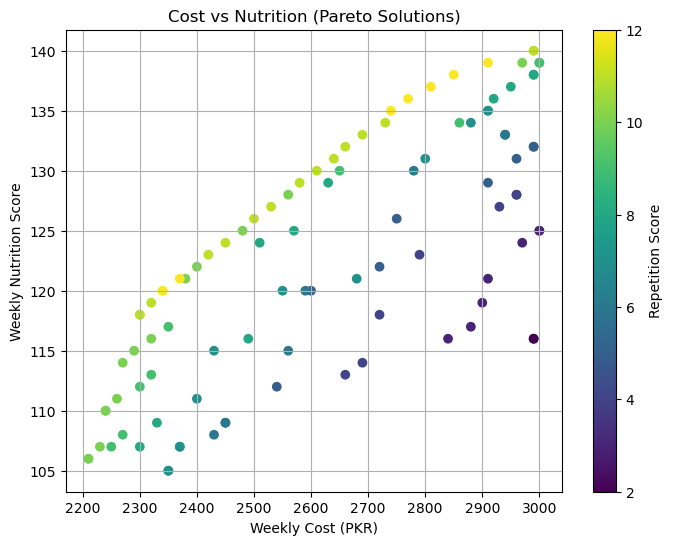


QUESTION - 4 (PART - 3a) COMPLETED


In [12]:
# QUESTION - 4
# PART - 3 (a)
# COST VS NUTRITION SCATTER PLOT

import matplotlib.pyplot as plt


# Using Pareto Front of Run-1

pareto_plans = all_runs[0]["pareto"]


cost_values = []
nutrition_values = []
repetition_values = []


# Store Objective Values

for solution in pareto_plans:

    objectives = solution["objectives"]

    cost_values.append(
        objectives["cost"]
    )

    nutrition_values.append(
        objectives["nutrition"]
    )

    repetition_values.append(
        objectives["repetition"]
    )


# Create Figure

plt.figure(figsize=(8,6))


# Scatter Plot

scatter = plt.scatter(

    cost_values,
    nutrition_values,
    c=repetition_values

)


# Color Bar

plt.colorbar(

    scatter,
    label="Repetition Score"

)


# Labels and Title

plt.xlabel("Weekly Cost (PKR)")

plt.ylabel("Weekly Nutrition Score")

plt.title(

    "Cost vs Nutrition (Pareto Solutions)"

)


# Grid

plt.grid(True)


# Display Plot

plt.show()


print("\nQUESTION - 4 (PART - 3a) COMPLETED")

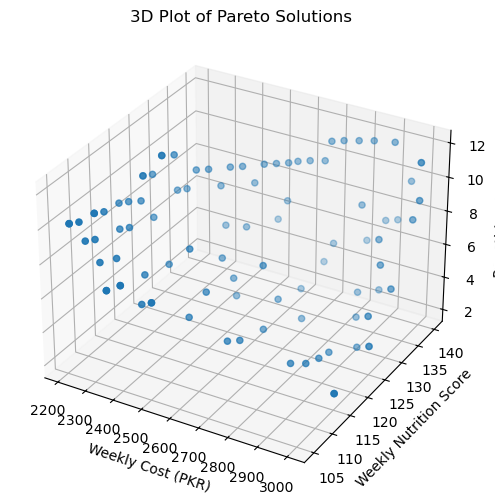


QUESTION - 4 (PART - 3b) COMPLETED


In [16]:
# QUESTION - 4
# PART - 3 (b)
# THREE DIMENSIONAL PLOT OF PARETO SOLUTIONS

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt


# Using Pareto Front of Run-1

pareto_plans = all_runs[0]["pareto"]


cost_values = []
nutrition_values = []
repetition_values = []


# Store Objective Values

for solution in pareto_plans:

    objectives = solution["objectives"]

    cost_values.append(
        objectives["cost"]
    )

    nutrition_values.append(
        objectives["nutrition"]
    )

    repetition_values.append(
        objectives["repetition"]
    )


# Create Figure

fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(
    111,
    projection="3d"
)


# Create 3D Scatter Plot

ax.scatter(

    cost_values,
    nutrition_values,
    repetition_values

)


# Axis Labels

ax.set_xlabel(
    "Weekly Cost (PKR)"
)

ax.set_ylabel(
    "Weekly Nutrition Score"
)

ax.set_zlabel(
    "Repetition Score"
)


# Title

ax.set_title(

    "3D Plot of Pareto Solutions"

)


# Display Plot

plt.show()


print("\nQUESTION - 4 (PART - 3b) COMPLETED")

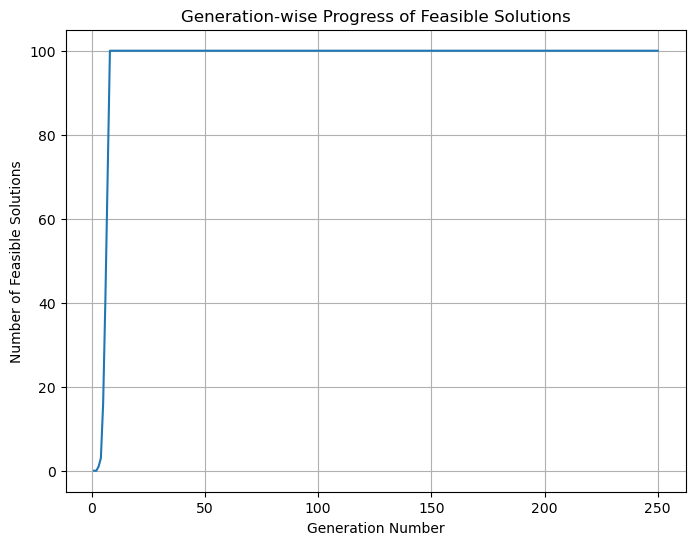


QUESTION - 4 (PART - 3c) COMPLETED


In [17]:
# QUESTION - 4
# PART - 3 (c)
# GENERATION-WISE PROGRESS PLOT


import matplotlib.pyplot as plt


# Generation Numbers

generation_numbers = list(
    range(1, GENERATIONS + 1)
)


# Create Figure

plt.figure(figsize=(8,6))


# Plot Feasible Solutions History

plt.plot(

    generation_numbers,
    feasible_history

)


# Labels

plt.xlabel(
    "Generation Number"
)

plt.ylabel(
    "Number of Feasible Solutions"
)


# Title

plt.title(

    "Generation-wise Progress of Feasible Solutions"

)


# Add Grid

plt.grid(True)


# Display Plot

plt.show()


print("\nQUESTION - 4 (PART - 3c) COMPLETED")

## uptil now i Have implemented all the requirements of Ques #4 and answers associated to this part is mentioned in my handwritten pdf

### Now I will move towards Question #5 Sensitive Analysis

In [18]:
# QUESTION - 5 (a)
# WEEKLY BUDGET = PKR 2300

print("\n" + "="*60)
print("QUESTION - 5 (a)")
print("REDUCED WEEKLY BUDGET (PKR 2300)")
print("="*60)

# SAVE ORIGINAL VALUE

original_budget = WEEKLY_BUDGET


# CHANGE ONLY ONE PARAMETER

WEEKLY_BUDGET = 2300


# 10 INDEPENDENT RUNS

NUMBER_OF_RUNS = 10

budget_results = []


for run_number in range(NUMBER_OF_RUNS):

    random.seed(run_number + 1)

    final_population, feasible_history = NSGA_II()


    feasible_solutions = [

        solution

        for solution in final_population

        if solution["violation"] == 0

    ]


    fronts = non_dominated_sort(final_population)

    pareto_front = fronts[0]


    budget_results.append(

        {

            "run" : run_number + 1,

            "feasible_count" :
            len(feasible_solutions),

            "pareto_count" :
            len(pareto_front),

            "population" :
            final_population

        }

    )


# DISPLAY RESULTS

print()

for result in budget_results:

    print(

        f"Run {result['run']} --> "
        f"Feasible : {result['feasible_count']} | "
        f"Pareto : {result['pareto_count']}"

    )


# AVERAGE RESULTS

average_feasible = (

    sum(

        result["feasible_count"]

        for result in budget_results

    )

    /

    NUMBER_OF_RUNS

)


average_pareto = (

    sum(

        result["pareto_count"]

        for result in budget_results

    )

    /

    NUMBER_OF_RUNS

)

print("\n" + "-"*60)
print(

    "Average Feasible Solutions :",

    round(average_feasible,2)

)
print(

    "Average Pareto Solutions :",

    round(average_pareto,2)
)
print("-"*60)


QUESTION - 5 (a)
REDUCED WEEKLY BUDGET (PKR 2300)

Run 1 --> Feasible : 100 | Pareto : 100
Run 2 --> Feasible : 100 | Pareto : 100
Run 3 --> Feasible : 100 | Pareto : 100
Run 4 --> Feasible : 100 | Pareto : 100
Run 5 --> Feasible : 100 | Pareto : 100
Run 6 --> Feasible : 100 | Pareto : 100
Run 7 --> Feasible : 100 | Pareto : 100
Run 8 --> Feasible : 100 | Pareto : 100
Run 9 --> Feasible : 100 | Pareto : 100
Run 10 --> Feasible : 100 | Pareto : 100

------------------------------------------------------------
Average Feasible Solutions : 100.0
Average Pareto Solutions : 100.0
------------------------------------------------------------


In [19]:
# Restore Original Weekly Budget

WEEKLY_BUDGET = 3000

print("Original Weekly Budget Restored Successfully.")

Original Weekly Budget Restored Successfully.


In [20]:
# QUESTION - 5 (b)
# MINIMUM DAILY NUTRITION = 24


print("\n" + "="*60)
print("QUESTION - 5 (b)")
print("MINIMUM DAILY NUTRITION (24)")
print("="*60)


# Store Original Value

original_nutrition = MINIMUM_DAILY_NUTRITION


# Apply New Constraint

MINIMUM_DAILY_NUTRITION = 24


# 10 Independent Runs

feasible_counts = []
pareto_counts = []


for run_number in range(10):

    random.seed(run_number + 1)

    final_population, feasible_history = NSGA_II()

    feasible_solutions = [

        solution for solution in final_population
        if solution["violation"] == 0

    ]

    fronts = non_dominated_sort(final_population)

    pareto_front = fronts[0]


    feasible_counts.append(
        len(feasible_solutions)
    )
    
    pareto_counts.append(
        len(pareto_front)
    )
    
    print(

        f"Run {run_number+1} --> "
        f"Feasible : {len(feasible_solutions)} "
        f"| Pareto : {len(pareto_front)}"

    )
print("\n" + "-"*60)

print(
    "Average Feasible Solutions :",
    sum(feasible_counts)/10
)
print(
    "Average Pareto Solutions :",
    sum(pareto_counts)/10
)
print("-"*60)


QUESTION - 5 (b)
MINIMUM DAILY NUTRITION (24)
Run 1 --> Feasible : 100 | Pareto : 100
Run 2 --> Feasible : 100 | Pareto : 100
Run 3 --> Feasible : 100 | Pareto : 100
Run 4 --> Feasible : 100 | Pareto : 100
Run 5 --> Feasible : 100 | Pareto : 100
Run 6 --> Feasible : 100 | Pareto : 100
Run 7 --> Feasible : 100 | Pareto : 100
Run 8 --> Feasible : 100 | Pareto : 100
Run 9 --> Feasible : 100 | Pareto : 100
Run 10 --> Feasible : 100 | Pareto : 100

------------------------------------------------------------
Average Feasible Solutions : 100.0
Average Pareto Solutions : 100.0
------------------------------------------------------------


In [21]:
# Restore Original Value

MINIMUM_DAILY_NUTRITION = original_nutrition

print(
    "\nOriginal Minimum Daily Nutrition Restored Successfully."
)


Original Minimum Daily Nutrition Restored Successfully.


In [22]:
# QUESTION - 5 (c)
# POPULATION SIZE COMPARISON

print("\n" + "="*60)
print("QUESTION - 5 (c)")
print("POPULATION SIZE COMPARISON")
print("="*60)

# Store Original Value

original_population_size = POPULATION_SIZE

# Population Sizes

population_sizes = [50, 100, 200]

for size in population_sizes:

    print(f"\nPOPULATION SIZE = {size}")
    print("-"*60)

    POPULATION_SIZE = size

    feasible_counts = []
    pareto_counts = []

    for run_number in range(10):

        random.seed(run_number + 1)

        final_population, feasible_history = NSGA_II()

        feasible_solutions = [

            solution for solution in final_population
            if solution["violation"] == 0

        ]


        fronts = non_dominated_sort(final_population)

        pareto_front = fronts[0]


        feasible_counts.append(
            len(feasible_solutions)
        )

        pareto_counts.append(
            len(pareto_front)
        )

    print(
        "Average Feasible Solutions :",
        sum(feasible_counts)/10
    )

    print(
        "Average Pareto Solutions :",
        sum(pareto_counts)/10
    )

# Restore Original Value

POPULATION_SIZE = original_population_size

print("\n" + "="*60)
print("ORIGINAL POPULATION SIZE RESTORED")
print("="*60)


QUESTION - 5 (c)
POPULATION SIZE COMPARISON

POPULATION SIZE = 50
------------------------------------------------------------
Average Feasible Solutions : 50.0
Average Pareto Solutions : 50.0

POPULATION SIZE = 100
------------------------------------------------------------
Average Feasible Solutions : 100.0
Average Pareto Solutions : 100.0

POPULATION SIZE = 200
------------------------------------------------------------
Average Feasible Solutions : 200.0
Average Pareto Solutions : 200.0

ORIGINAL POPULATION SIZE RESTORED


In [23]:
# QUESTION - 5 (d)
# MUTATION PROBABILITY COMPARISON

print("\n" + "="*60)
print("QUESTION - 5 (d)")
print("MUTATION PROBABILITY COMPARISON")
print("="*60)


mutation_values = [0.02, 0.05, 0.10]

for mutation_value in mutation_values:

    MUTATION_PROBABILITY = mutation_value

    feasible_results = []
    pareto_results = []

    for run_number in range(10):

        random.seed(run_number + 1)

        final_population, feasible_history = NSGA_II()

        feasible_solutions = [

            solution for solution in final_population

            if solution["violation"] == 0

        ]

        fronts = non_dominated_sort(final_population)

        pareto_front = fronts[0]

        feasible_results.append(
            len(feasible_solutions)
        )

        pareto_results.append(
            len(pareto_front)
        )

    print(f"\nMUTATION PROBABILITY = {mutation_value}")
    print("-"*60)

    print(

        "Average Feasible Solutions :",

        sum(feasible_results) /
        len(feasible_results)
    )
    
    print(

        "Average Pareto Solutions :",

        sum(pareto_results) /
        len(pareto_results)

    )

# Restore Original Value

MUTATION_PROBABILITY = 0.05

print("\n" + "="*60)
print("ORIGINAL MUTATION PROBABILITY RESTORED")
print("="*60)


QUESTION - 5 (d)
MUTATION PROBABILITY COMPARISON

MUTATION PROBABILITY = 0.02
------------------------------------------------------------
Average Feasible Solutions : 100.0
Average Pareto Solutions : 100.0

MUTATION PROBABILITY = 0.05
------------------------------------------------------------
Average Feasible Solutions : 100.0
Average Pareto Solutions : 100.0

MUTATION PROBABILITY = 0.1
------------------------------------------------------------
Average Feasible Solutions : 100.0
Average Pareto Solutions : 100.0

ORIGINAL MUTATION PROBABILITY RESTORED


In [24]:
# QUESTION - 5 (e)
# TWO OBJECTIVES ONLY
# (COST + NUTRITION)



# TEMPORARY DOMINANCE FUNCTION (2 OBJECTIVES)

def dominates(solution1, solution2):

    # Prefer Feasible Solutions

    if solution1["violation"] == 0 and solution2["violation"] > 0:
        return True

    if solution1["violation"] > 0 and solution2["violation"] == 0:
        return False


    # If Both Solutions are Infeasible

    if (solution1["violation"] > 0 and
            solution2["violation"] > 0):

        return (

            solution1["violation"] <
            solution2["violation"]

        )


    # Cost Objective

    cost_better = (

        solution1["objectives"]["cost"]
        <=
        solution2["objectives"]["cost"]

    )


    # Nutrition Objective

    nutrition_better = (

        solution1["objectives"]["negative_nutrition"]
        <=
        solution2["objectives"]["negative_nutrition"]

    )


    # At Least One Strictly Better

    strictly_better = (

        solution1["objectives"]["cost"]
        <
        solution2["objectives"]["cost"]

        or

        solution1["objectives"]["negative_nutrition"]
        <
        solution2["objectives"]["negative_nutrition"]

    )


    return (

        cost_better
        and
        nutrition_better
        and
        strictly_better

    )


# TEMPORARY CROWDING DISTANCE (2 OBJECTIVES)

def calculate_crowding_distance(front):

    if len(front) == 0:
        return


    if len(front) <= 2:

        for solution in front:

            solution["crowding_distance"] = float("inf")

        return

    for solution in front:

        solution["crowding_distance"] = 0


    objectives = [

        "cost",
        "negative_nutrition"

    ]

    for objective in objectives:


        front.sort(

            key=lambda x:
            x["objectives"][objective]

        )

        front[0]["crowding_distance"] = float("inf")
        front[-1]["crowding_distance"] = float("inf")


        minimum = front[0]["objectives"][objective]
        maximum = front[-1]["objectives"][objective]

        if minimum == maximum:
            continue

        for i in range(1, len(front)-1):

            previous_value = (

                front[i-1]["objectives"][objective]

            )


            next_value = (

                front[i+1]["objectives"][objective]

            )


            distance = (

                (next_value - previous_value)

                /

                (maximum - minimum)

            )

            if front[i]["crowding_distance"] != float("inf"):

                front[i]["crowding_distance"] += distance

print("\nTemporary Two-Objective NSGA-II Activated.")
print("Objectives : Cost + Nutrition")


Temporary Two-Objective NSGA-II Activated.
Objectives : Cost + Nutrition


In [25]:
# QUESTION - 5 (e)
# COST + NUTRITION ONLY

print("\n" + "="*60)
print("QUESTION - 5 (e)")
print("COST + NUTRITION OBJECTIVES ONLY")
print("="*60)


feasible_results = []
pareto_results = []


for run_number in range(10):

    random.seed(run_number + 1)

    final_population, feasible_history = NSGA_II()


    feasible_solutions = [

        solution for solution in final_population

        if solution["violation"] == 0

    ]


    fronts = non_dominated_sort(final_population)

    pareto_front = fronts[0]


    feasible_results.append(
        len(feasible_solutions)
    )

    pareto_results.append(
        len(pareto_front)
    )


    print(

        f"Run {run_number + 1} --> "
        f"Feasible : {len(feasible_solutions)} "
        f"| Pareto : {len(pareto_front)}"

    )


print("\n" + "-"*60)

print(

    "Average Feasible Solutions :",

    sum(feasible_results) /
    len(feasible_results)

)

print(

    "Average Pareto Solutions :",

    sum(pareto_results) /
    len(pareto_results)

)

print("-"*60)


# RESTORE ORIGINAL THREE-OBJECTIVE NSGA-II

# ORIGINAL DOMINANCE FUNCTION

def dominates(solution1, solution2):

    if solution1["violation"] == 0 and solution2["violation"] > 0:
        return True

    if solution1["violation"] > 0 and solution2["violation"] == 0:
        return False


    if (solution1["violation"] > 0 and
            solution2["violation"] > 0):

        return (

            solution1["violation"] <
            solution2["violation"]

        )


    cost_better = (

        solution1["objectives"]["cost"]
        <=
        solution2["objectives"]["cost"]

    )


    nutrition_better = (

        solution1["objectives"]["negative_nutrition"]
        <=
        solution2["objectives"]["negative_nutrition"]

    )


    repetition_better = (

        solution1["objectives"]["repetition"]
        <=
        solution2["objectives"]["repetition"]

    )


    strictly_better = (

        solution1["objectives"]["cost"]
        <
        solution2["objectives"]["cost"]

        or

        solution1["objectives"]["negative_nutrition"]
        <
        solution2["objectives"]["negative_nutrition"]

        or

        solution1["objectives"]["repetition"]
        <
        solution2["objectives"]["repetition"]

    )


    return (

        cost_better
        and
        nutrition_better
        and
        repetition_better
        and
        strictly_better

    )


# ORIGINAL CROWDING DISTANCE FUNCTION

def calculate_crowding_distance(front):

    if len(front) == 0:
        return


    if len(front) <= 2:

        for solution in front:

            solution["crowding_distance"] = float("inf")

        return

    for solution in front:

        solution["crowding_distance"] = 0


    objectives = [

        "cost",
        "negative_nutrition",
        "repetition"

    ]

    for objective in objectives:


        front.sort(

            key=lambda x:
            x["objectives"][objective]

        )


        front[0]["crowding_distance"] = float("inf")
        front[-1]["crowding_distance"] = float("inf")


        minimum = front[0]["objectives"][objective]
        maximum = front[-1]["objectives"][objective]


        if minimum == maximum:
            continue

        for i in range(1, len(front)-1):

            previous_value = (

                front[i-1]["objectives"][objective]

            )

            next_value = (

                front[i+1]["objectives"][objective]

            )

            distance = (

                (next_value - previous_value)

                /

                (maximum - minimum)

            )


            if front[i]["crowding_distance"] != float("inf"):

                front[i]["crowding_distance"] += distance

print("\n" + "="*60)
print("ORIGINAL THREE-OBJECTIVE NSGA-II RESTORED")
print("="*60)


QUESTION - 5 (e)
COST + NUTRITION OBJECTIVES ONLY
Run 1 --> Feasible : 100 | Pareto : 100
Run 2 --> Feasible : 100 | Pareto : 100
Run 3 --> Feasible : 100 | Pareto : 100
Run 4 --> Feasible : 100 | Pareto : 100
Run 5 --> Feasible : 100 | Pareto : 100
Run 6 --> Feasible : 100 | Pareto : 100
Run 7 --> Feasible : 100 | Pareto : 100
Run 8 --> Feasible : 100 | Pareto : 100
Run 9 --> Feasible : 100 | Pareto : 100
Run 10 --> Feasible : 100 | Pareto : 100

------------------------------------------------------------
Average Feasible Solutions : 100.0
Average Pareto Solutions : 100.0
------------------------------------------------------------

ORIGINAL THREE-OBJECTIVE NSGA-II RESTORED
